In [1]:
import numpy as np

## Here are the functions we need for this

In [2]:
predict = lambda x, w, b: np.matmul(w,x.T) + b
sigmoid = lambda yhat: 1/(1+np.exp(-yhat))
loss = lambda y, sigmoid: -(y*np.log(sigmoid)+(1-y)*np.log(1-sigmoid)).mean()
dldw = lambda x, y, sigmoid: (np.reshape(sigmoid-y,(50,1))*x).mean(axis = 0)
dldb = lambda y, sig: (sig-y).mean(axis = 0)
update = lambda a, g, lr: a-(g*lr)

In [3]:
#b and w are the initial weights all set to 0
def GradDescent(X, y, n_iter, alpha, b = 0, w = None):
    if(w == None):
        w = np.zeros(X.shape[1])
    learning_rate = alpha
    for i in range(n_iter):
        yhat = predict(X,w,b)
        sig = sigmoid(yhat)
        grad_w = dldw(X,y,sig)
        grad_b = dldb(y,sig)
        w = update(w,grad_w,learning_rate)
        b = update(b,grad_b,learning_rate)
    return b,w

To demonstrate this, let's make some random data


In [4]:
from sklearn.datasets import make_classification

In [5]:
clasData = make_classification(n_features = 5, n_samples = 50,random_state = 4)

x=clasData[0]
y=clasData[1]

In [6]:
y

array([1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 1])

This gives us dummy classification data with 5 features and 50 in our sample

In [7]:
GradDescent(x, y, 2000, 1)

(-0.728933077054689,
 array([-0.12818396, -0.28864804, -1.11075534,  0.14203945,  2.54489187]))

Compare with LogisticRegression

In [8]:
from sklearn.linear_model import LogisticRegression

In [9]:
model = LogisticRegression()
model.fit(x,y)
print(model.intercept_,model.coef_)

[-0.46409325] [[-0.11454056 -0.19867916 -0.76230193  0.13371286  1.77306092]]


It's not the same :(

In [10]:
LogisticRegression?

Init signature:
LogisticRegression(
    penalty='deprecated',
    *,
    C=1.0,
    l1_ratio=0.0,
    dual=False,
    tol=0.0001,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver='lbfgs',
    max_iter=100,
    verbose=0,
    warm_start=False,
    n_jobs=None,
)
Docstring:     
Logistic Regression (aka logit, MaxEnt) classifier.

This class implements regularized logistic regression using a set of available
solvers. **Note that regularization is applied by default**. It can handle both
dense and sparse input `X`. Use C-ordered arrays or CSR matrices containing 64-bit
floats for optimal performance; any other input format will be converted (and
copied).

The solvers 'lbfgs', 'newton-cg', 'newton-cholesky' and 'sag' support only L2
regularization with primal formulation, or no regularization. The 'liblinear'
solver supports both L1 and L2 regularization (but not both, i.e. elastic-net),
with a dual formulation only for the L2 penalt

Oh LogisticRegression applies l2 regularisation by default, let's see what happens if we remove that

In [11]:
model = LogisticRegression(penalty=None)
model.fit(x,y)
print(model.intercept_,model.coef_)

[-0.7294786] [[-0.1286427  -0.28868951 -1.11091014  0.14213717  2.54530356]]


/opt/anaconda3/envs/ml_lab/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


That's a lot closer!

## Let's do regularisation ourselves

loss and dldw are the things we need to change


In [12]:
lossreg = lambda y, sigmoid, l, w: -(y*np.log(sigmoid)+(1-y)*np.log(1-sigmoid)).mean()+ l/(2*len(y))*(w**2).sum()
dldwreg = lambda x, y, sigmoid, l, w: (np.reshape(sigmoid-y,(50,1))*x).mean(axis = 0) + (l/len(y))*w

In [13]:
def GradDescentwithReg(x, y, n_iter, alpha, b = 0, w = None, l = 1):
    if(w == None):
        w = np.zeros(x.shape[1])
    learning_rate = alpha
    for i in range(n_iter):
        yhat = predict(x,w,b)
        sig = sigmoid(yhat)
        grad_w = dldwreg(x,y,sig, l, w)
        grad_b = dldb(y,sig)
        w = update(w,grad_w,learning_rate)
        b = update(b,grad_b,learning_rate)
    return b,w

In [14]:
GradDescentwithReg(x, y, 1000, 1, l=1)

(-0.4637283533516529,
 array([-0.11404314, -0.19874293, -0.76255704,  0.1335889 ,  1.77353078]))

And that's pretty close to the regularised form from sklearn

## Different amount of regularisation?

In [15]:
GradDescentwithReg(x, y, 1000, 1, l=0.1)

(-0.6804317671624746,
 array([-0.12797542, -0.2718795 , -1.04574135,  0.14158971,  2.40169268]))

In [16]:
model = LogisticRegression(C = 0.1)
model.fit(x,y)
model.intercept_,model.coef_

(array([-0.14113474]),
 array([[-0.06341149, -0.08722689, -0.33349014,  0.0777289 ,  0.78975353]]))

Agh it's different again, why sklearn?

# RTM

C is not the same as $\lambda$, C is actually $\frac{1}{\lambda}$

In [17]:
model = LogisticRegression(C = 1/0.1)
model.fit(x,y)
model.intercept_,model.coef_

(array([-0.67934588]),
 array([[-0.12673464, -0.27188166, -1.04576448,  0.14135291,  2.40157016]]))

Phew we're ok!

Always important to read the manual and see what they actually mean about the equivalent variables

In [18]:
def GradDescentwithRegPlot(x, y, n_iter, alpha, b = 0, w = None, l = 1):
    if(w == None):
        w = np.zeros(x.shape[1])
    learning_rate = alpha
    losses = []
    for i in range(n_iter):
        yhat = predict(x,w,b)
        sig = sigmoid(yhat)

        logloss = lossreg(y,sig,l, w)
        losses.append(logloss)
        
        grad_w = dldwreg(x,y,sig, l, w)
        grad_b = dldb(y,sig)
        w = update(w,grad_w,learning_rate)
        b = update(b,grad_b,learning_rate)
    return losses, b, w

In [19]:
losses, _, _ = GradDescentwithRegPlot(x, y, 1000, 0.1, l=0.1)

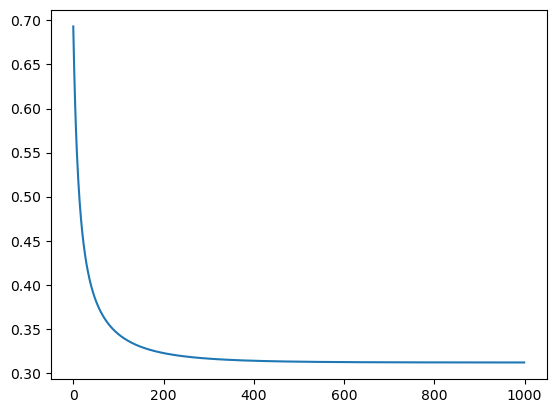

In [20]:
import matplotlib.pyplot as plt
plt.plot(losses)